# Imports

In [1]:
import os
import numpy as np
import cv2
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from matplotlib.lines import Line2D
import matplotlib.animation as animation
from IPython.display import HTML
import math
import pandas as pd
import random
from scipy.stats import wilcoxon



# Getting the Data

In [2]:
# Base directory for outputs
BASE_DIR = "."

In [3]:
# Load synthetic data (cameras and ground truth)
data_file = os.path.join(
    BASE_DIR,
    "synthetic_fish_multiview_3cams_inside_tank.npz"
)

gt_file = os.path.join(
    BASE_DIR,
    "synthetic_fish_3d_gt.npz"
)

data = np.load(data_file, allow_pickle=True)
gt_data = np.load(gt_file, allow_pickle=True)


In [4]:
# Ground truth 3D positions [Time, Fish_ID, Coordinates]
pos3d_gt = data["pos3d_gt"]
dt = float(gt_data.get("dt", 0.033)) # Time step between frames

# Camera parameters for 3 cameras
cams = []
for i in range(3):
    cams.append({
        'K': data[f'cam{i}_K'],
        'R': data[f'cam{i}_R'],
        't': data[f'cam{i}_t'],
        'dist': data[f'cam{i}_dist'],
        'uv': data[f'cam{i}_uv'],    # 2D tracking points (tracklets)
        'vis': data[f'cam{i}_vis'],   # Visibility mask
        'conf': data[f'cam{i}_conf'] #confidence
    })

In [5]:
T, N, _ = pos3d_gt.shape  
total_frames = T

In [6]:
rows = []

for key in gt_data.files:
    arr = gt_data[key]
    rows.append({
        "Variable": key,
        "Shape": arr.shape,
        "Type": arr.dtype
    })

pd.DataFrame(rows)

,Variable,Shape,Type
0,pos,"(600, 8, 3)",float64
1,vel,"(600, 8, 3)",float64
2,n_fish,(),int64
3,tank_size,"(3,)",float64
4,dt,(),float64
5,note,(),<U18


# Triangulation

## Execution

In [7]:
# To implement P = K[R|t], which is the standard camera projection matrix
def build_projection_matrix(K, R, t):
    t_vec = np.asarray(t).reshape(3, 1)
    Rt = np.hstack([R, t_vec])
    return K @ Rt

# To remove lens distortion from 2D points
def undistort_points(pt, K, dist):
    pt = np.asarray(pt, dtype=np.float32).reshape(1, 1, 2)
    dist_vec = np.asarray(dist).flatten()
    if dist_vec.shape[0] == 2:
        dist_vec = np.array([dist_vec[0], dist_vec[1], 0, 0], dtype=np.float32)
    undistorted = cv2.undistortPoints(pt, K, dist_vec, P=K)
    return undistorted.reshape(2)

In [8]:
# Multi-view linear triangulation using SVD (Singular Value Decomposition)
def triangulate_dlt(points, projections):
    A = []
    for (u, v), P in zip(points, projections):
        A.append(u * P[2, :] - P[0, :])
        A.append(v * P[2, :] - P[1, :])
    A = np.asarray(A, dtype=np.float64)
    _, _, Vt = np.linalg.svd(A)
    X_h = Vt[-1]
    return X_h[:3] / X_h[3]

In [9]:
X_est_geo = np.full((T, N, 3), np.nan)
proj_matrices = [build_projection_matrix(c['K'], c['R'], c['t']) for c in cams]

for t in range(T):
    for n in range(N):
        pts_frame = []
        projs_frame = []
        for i in range(3):
            if cams[i]['vis'][t, n]:
                pt = undistort_points(cams[i]['uv'][t, n], cams[i]['K'], cams[i]['dist'])
                pts_frame.append(pt)
                projs_frame.append(proj_matrices[i])

        if len(pts_frame) >= 2:
            X_est_geo[t, n] = triangulate_dlt(pts_frame, projs_frame)


## Results

In [10]:
# Error per fish
print("GEOMETRIC TRIANGULATION RESULTS")
for n in range(N):
    valid = np.isfinite(X_est_geo[:, n, :]).all(axis=1) & np.isfinite(pos3d_gt[:, n, :]).all(axis=1)
    if valid.sum() > 0:
        err = np.linalg.norm(X_est_geo[valid, n, :] - pos3d_gt[valid, n, :], axis=1)
        print(f"Fish {n}: {valid.sum():3d} triangulated frames | "
              f"Mean Error = {err.mean():.4f} m | "
              f"Max Error = {err.max():.4f} m")
    else:
        print(f"Fish {n}: no triangulated frames")

GEOMETRIC TRIANGULATION RESULTS
Fish 0: 241 triangulated frames | Mean Error = 0.0133 m | Max Error = 0.0838 m
Fish 1: 204 triangulated frames | Mean Error = 0.0129 m | Max Error = 0.0467 m
Fish 2: 194 triangulated frames | Mean Error = 0.0133 m | Max Error = 0.0671 m
Fish 3: 221 triangulated frames | Mean Error = 0.0128 m | Max Error = 0.0821 m
Fish 4: 141 triangulated frames | Mean Error = 0.0166 m | Max Error = 0.0948 m
Fish 5: 241 triangulated frames | Mean Error = 0.0132 m | Max Error = 0.0766 m
Fish 6: 175 triangulated frames | Mean Error = 0.0151 m | Max Error = 0.1527 m
Fish 7: 285 triangulated frames | Mean Error = 0.0121 m | Max Error = 0.0654 m


In [11]:
# Overall
valid_mask = np.isfinite(X_est_geo).all(axis=2) & np.isfinite(pos3d_gt).all(axis=2)
overall_err = np.linalg.norm(X_est_geo[valid_mask] - pos3d_gt[valid_mask], axis=1)
print(f"\nOverall: {valid_mask.sum()} triangulated fish-frames ({valid_mask.sum()/(T*N)*100:.1f}%)")
print(f"Mean Error = {overall_err.mean():.4f} m")
print(f"Std  Error = {overall_err.std():.4f} m")
print(f"Max  Error = {overall_err.max():.4f} m")


Overall: 1702 triangulated fish-frames (35.5%)
Mean Error = 0.0134 m
Std  Error = 0.0105 m
Max  Error = 0.1527 m


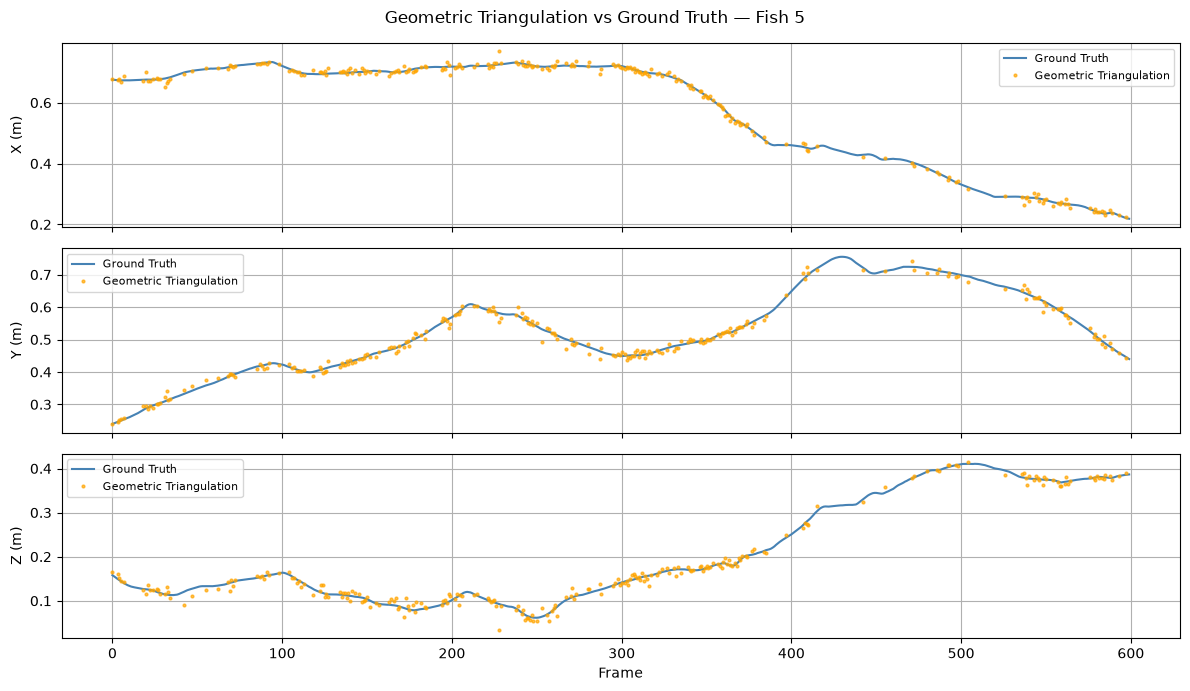

In [12]:
# Plot for one fish
fish_idx = 5 #choose the fish you wanna see
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
labels = ['X', 'Y', 'Z']
for d, ax in enumerate(axes):
    ax.plot(pos3d_gt[:, fish_idx, d], label='Ground Truth', color='steelblue')
    ax.plot(X_est_geo[:, fish_idx, d], 'o', markersize=2, 
            label='Geometric Triangulation', color='orange', alpha=0.7)
    ax.set_ylabel(f'{labels[d]} (m)')
    ax.legend(fontsize=8)
    ax.grid(True)
axes[-1].set_xlabel('Frame')
fig.suptitle(f'Geometric Triangulation vs Ground Truth — Fish {fish_idx}')
plt.tight_layout()
plt.show()

# Preparing for EDA

In [13]:
#fills missing 3D position values using interpolation and calculates 
# the difference between the estimated positions and the ground truth.
def fill_missing_data(arr):
    out = arr.copy()
    for n in range(arr.shape[1]):
        for d in range(3):
            series = out[:, n, d]
            valid = np.isfinite(series)
            if np.any(valid):
                idx = np.arange(len(series))
                out[:, n, d] = np.interp(idx, idx[valid], series[valid])
    return out

X_filled = fill_missing_data(X_est_geo)

target_delta = pos3d_gt - X_filled


## Masks

In [14]:
# Frames where geometry gave a real estimate (not interpolated)
triangulated_mask = np.isfinite(X_est_geo).all(axis=2) & np.isfinite(pos3d_gt).all(axis=2)

# All frames where GT exists (for full occlusion evaluation)
all_gt_mask = np.isfinite(pos3d_gt).all(axis=2)

# Exploratory Data Analysis

## Dataset Overview

In [15]:
print(f"Total frames     : {T}")
print(f"Number of fish   : {N}")
print(f"Number of cameras: 3")
print(f"Time step (dt)   : {dt:.4f} s  ({1/dt:.1f} fps)")
print(f"Total duration   : {T * dt:.2f} s")
print(f"3D GT shape      : {pos3d_gt.shape}")

Total frames     : 600
Number of fish   : 8
Number of cameras: 3
Time step (dt)   : 0.0333 s  (30.0 fps)
Total duration   : 20.00 s
3D GT shape      : (600, 8, 3)


## Ground Truth Trajectory Statistics

In [17]:
# Prints the minimum and maximum 3D coordinates (X, Y, and Z) of each fish 
# in the ground truth data.
print("Ground Truth 3D ranges:")
for n in range(N):
    pos = pos3d_gt[:, n, :]
    valid = np.isfinite(pos).all(axis=1)
    print(f"  Fish {n}: X={pos[valid,0].min():.2f}–{pos[valid,0].max():.2f}m  "
          f"Y={pos[valid,1].min():.2f}–{pos[valid,1].max():.2f}m  "
          f"Z={pos[valid,2].min():.2f}–{pos[valid,2].max():.2f}m")

Ground Truth 3D ranges:
  Fish 0: X=0.23–0.78m  Y=0.26–0.74m  Z=0.08–0.45m
  Fish 1: X=0.06–0.53m  Y=0.19–0.74m  Z=0.06–0.30m
  Fish 2: X=0.05–0.32m  Y=0.05–0.75m  Z=0.17–0.45m
  Fish 3: X=0.06–0.35m  Y=0.06–0.56m  Z=0.06–0.28m
  Fish 4: X=0.26–0.86m  Y=0.45–0.74m  Z=0.07–0.46m
  Fish 5: X=0.22–0.73m  Y=0.24–0.76m  Z=0.06–0.41m
  Fish 6: X=0.27–0.89m  Y=0.27–0.78m  Z=0.07–0.27m
  Fish 7: X=0.08–0.53m  Y=0.12–0.48m  Z=0.05–0.45m


## Visibility of Fishes

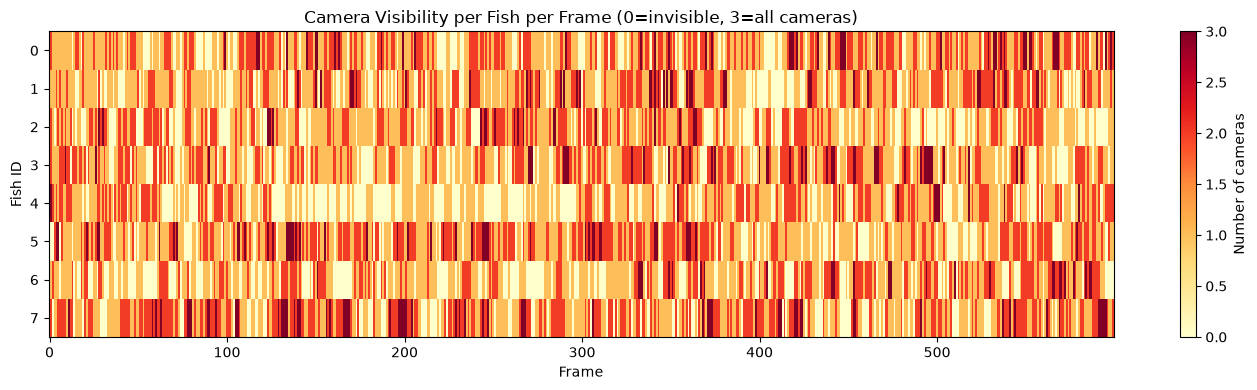

In [18]:
# Shows how many cameras can see each fish in each frame using a visibility heatmap
vis_matrix = np.zeros((T, N))
for n in range(N):
    for i in range(3):
        vis_matrix[:, n] += cams[i]['vis'][:, n].astype(int)

plt.figure(figsize=(14, 4))
plt.imshow(vis_matrix.T, aspect='auto', cmap='YlOrRd', interpolation='none')
plt.colorbar(label='Number of cameras')
plt.xlabel('Frame')
plt.ylabel('Fish ID')
plt.title('Camera Visibility per Fish per Frame (0=invisible, 3=all cameras)')
plt.tight_layout()
plt.show()

In [19]:
#Calculates and prints the number and percentage of frames 
# in which each fish is visible in 0, 1, 2, or 3 cameras.
for n in range(N):
    vis_per_frame = np.stack([cams[i]['vis'][:, n] for i in range(3)], axis=1)  # (T, 3)
    cam_counts = vis_per_frame.sum(axis=1)

    print(f"Fish {n}:")
    print(f"  3-camera frames : {(cam_counts == 3).sum()}  ({(cam_counts == 3).sum()/T*100:.1f}%)")
    print(f"  2-camera frames : {(cam_counts == 2).sum()}  ({(cam_counts == 2).sum()/T*100:.1f}%)")
    print(f"  1-camera frames : {(cam_counts == 1).sum()}  ({(cam_counts == 1).sum()/T*100:.1f}%)")
    print(f"  0-camera frames : {(cam_counts == 0).sum()}  ({(cam_counts == 0).sum()/T*100:.1f}%)")
    print()

Fish 0:
  3-camera frames : 45  (7.5%)
  2-camera frames : 196  (32.7%)
  1-camera frames : 267  (44.5%)
  0-camera frames : 92  (15.3%)

Fish 1:
  3-camera frames : 40  (6.7%)
  2-camera frames : 164  (27.3%)
  1-camera frames : 277  (46.2%)
  0-camera frames : 119  (19.8%)

Fish 2:
  3-camera frames : 20  (3.3%)
  2-camera frames : 174  (29.0%)
  1-camera frames : 259  (43.2%)
  0-camera frames : 147  (24.5%)

Fish 3:
  3-camera frames : 41  (6.8%)
  2-camera frames : 180  (30.0%)
  1-camera frames : 266  (44.3%)
  0-camera frames : 113  (18.8%)

Fish 4:
  3-camera frames : 10  (1.7%)
  2-camera frames : 131  (21.8%)
  1-camera frames : 267  (44.5%)
  0-camera frames : 192  (32.0%)

Fish 5:
  3-camera frames : 45  (7.5%)
  2-camera frames : 196  (32.7%)
  1-camera frames : 268  (44.7%)
  0-camera frames : 91  (15.2%)

Fish 6:
  3-camera frames : 26  (4.3%)
  2-camera frames : 149  (24.8%)
  1-camera frames : 261  (43.5%)
  0-camera frames : 164  (27.3%)

Fish 7:
  3-camera frames : 6

## Triangulable vs Non-Triangulable Frames

In [20]:
# Frames with ≥2 cameras 
triangulable = (vis_matrix >= 2)
print("Triangulable frames (≥2 cameras):")
for n in range(N):
    pct = triangulable[:, n].sum() / T * 100
    print(f"  Fish {n}: {triangulable[:, n].sum()}/600 frames ({pct:.1f}%)")

# Overall
overall = triangulable.sum() / (T * N) * 100
print(f"\nOverall triangulable: {overall:.1f}% of all fish-frames")

Triangulable frames (≥2 cameras):
  Fish 0: 241/600 frames (40.2%)
  Fish 1: 204/600 frames (34.0%)
  Fish 2: 194/600 frames (32.3%)
  Fish 3: 221/600 frames (36.8%)
  Fish 4: 141/600 frames (23.5%)
  Fish 5: 241/600 frames (40.2%)
  Fish 6: 175/600 frames (29.2%)
  Fish 7: 285/600 frames (47.5%)

Overall triangulable: 35.5% of all fish-frames


## 3D Trajectory Plot

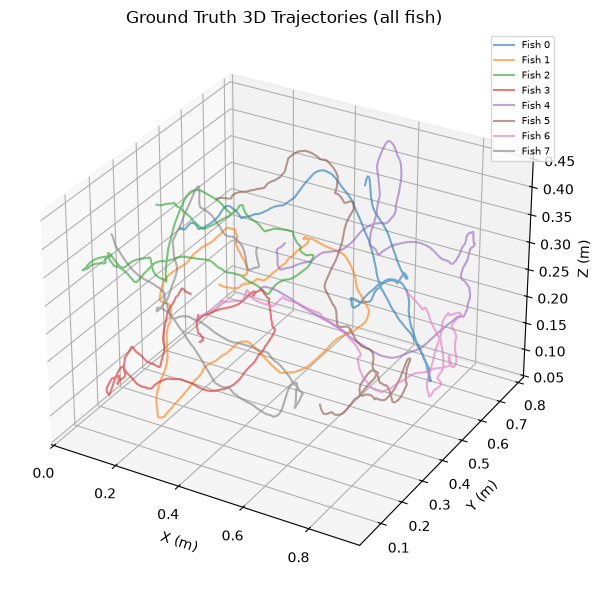

In [22]:
# Plots the ground truth 3D trajectories of all fish, 
# showing their movement in X, Y, and Z coordinates
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
for n in range(N):
    pos = pos3d_gt[:, n, :]
    valid = np.isfinite(pos).all(axis=1)
    ax.plot(pos[valid, 0], pos[valid, 1], pos[valid, 2], alpha=0.6, label=f'Fish {n}')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Ground Truth 3D Trajectories (all fish)')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

### VISIBILITY PER FISH-FRAME


Visibility distribution

0 cameras : 1013 observations (21.10%)
1 cameras : 2085 observations (43.44%)
2 cameras : 1409 observations (29.35%)
3 cameras : 293 observations (6.10%)

Triangulable observations: 1702 / 4800


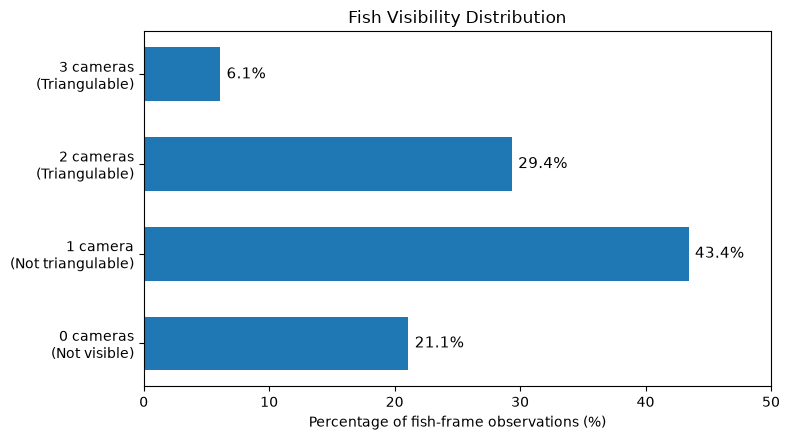

In [23]:
#Calculates and visualizes the percentage of fish-frame observations 
#visible in 0, 1, 2, or 3 cameras, highlighting which observations can be triangulated.
visibility_count = (
    cams[0]["vis"].astype(int)
    + cams[1]["vis"].astype(int)
    + cams[2]["vis"].astype(int)
)

categories, counts = np.unique(visibility_count, return_counts=True)

total = visibility_count.size
percentages = counts / total * 100

print("Visibility distribution\n")

for c, n, p in zip(categories, counts, percentages):
    print(f"{c} cameras : {n} observations ({p:.2f}%)")

print(
    f"\nTriangulable observations: "
    f"{np.sum(visibility_count>=2)} / {total}"
)

labels = [
    "0 cameras\n(Not visible)",
    "1 camera\n(Not triangulable)",
    "2 cameras\n(Triangulable)",
    "3 cameras\n(Triangulable)"
]

values = percentages

plt.figure(figsize=(8,4.5))

bars = plt.barh(
    labels,
    values,
    height=0.6
)

for bar,v in zip(bars,values):
    plt.text(
        v+0.5,
        bar.get_y()+bar.get_height()/2,
        f"{v:.1f}%",
        va="center",
        fontsize=11
    )

plt.xlabel("Percentage of fish-frame observations (%)")
plt.title("Fish Visibility Distribution")

plt.xlim(0,50)

plt.tight_layout()
plt.show()

## Target Delta Distribution 

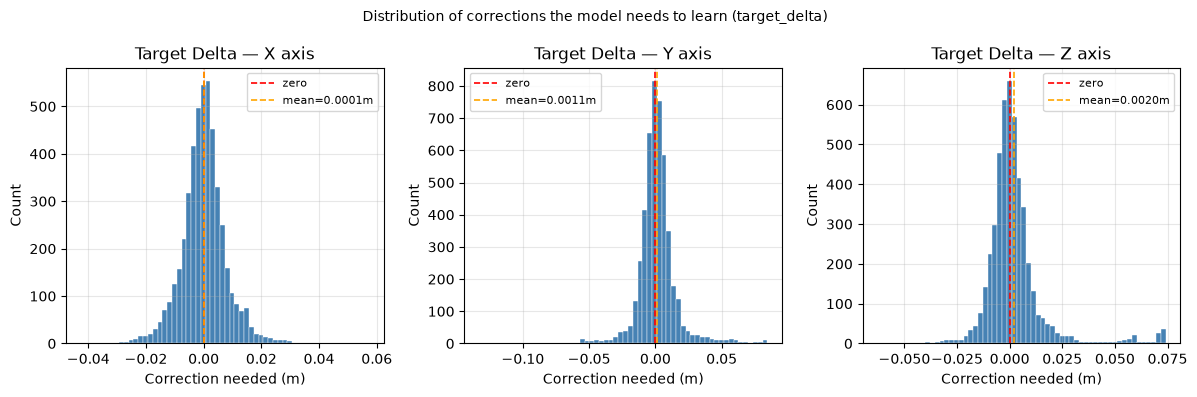

In [24]:
#Shows the distribution of the 3D corrections in X, Y, and Z that the model needs to 
# learn to improve the geometric estimates.
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
labels = ['X', 'Y', 'Z']

for d, ax in enumerate(axes):
    deltas = target_delta[all_gt_mask, d]
    ax.hist(deltas, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='zero')
    ax.axvline(deltas.mean(), color='orange', linestyle='--', linewidth=1.2, 
               label=f'mean={deltas.mean():.4f}m')
    ax.set_title(f'Target Delta — {labels[d]} axis')
    ax.set_xlabel('Correction needed (m)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution of corrections the model needs to learn (target_delta)', 
             fontsize=10)
plt.tight_layout()
plt.show()

In [25]:
print("Target delta statistics (all GT frames):")
for d, label in enumerate(labels):
    deltas = target_delta[all_gt_mask, d]
    print(f"  {label}: mean={deltas.mean():.4f}m  std={deltas.std():.4f}m  "
          f"min={deltas.min():.4f}m  max={deltas.max():.4f}m")

Target delta statistics (all GT frames):
  X: mean=0.0001m  std=0.0078m  min=-0.0426m  max=0.0573m
  Y: mean=0.0011m  std=0.0149m  min=-0.1332m  max=0.0844m
  Z: mean=0.0020m  std=0.0143m  min=-0.0630m  max=0.0741m


## Triangulation Error per Axis

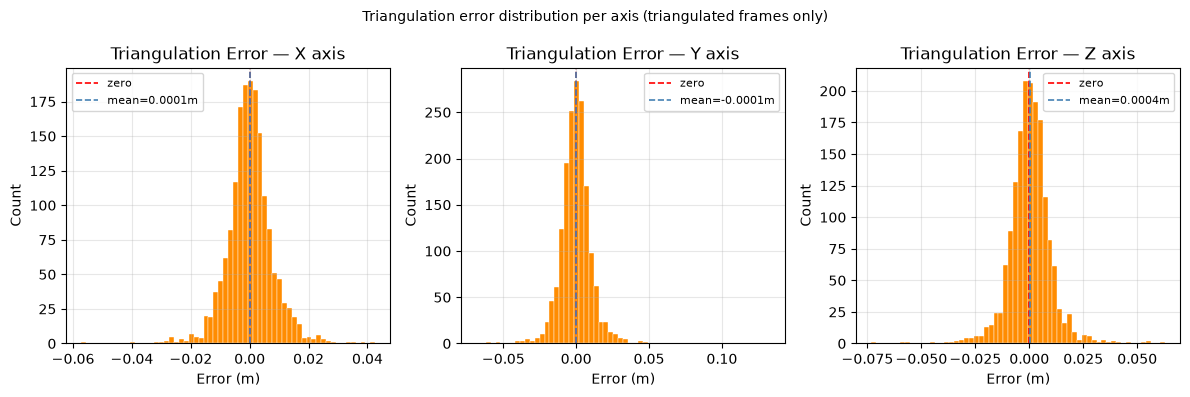

In [26]:
#Shows the distribution of triangulation errors along the X, Y, and Z axes 
# for frames with valid 3D reconstruction.
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for d, ax in enumerate(axes):
    err = (X_est_geo[valid_mask, d] - pos3d_gt[valid_mask, d])
    ax.hist(err, bins=60, color='darkorange', edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='zero')
    ax.axvline(err.mean(), color='steelblue', linestyle='--', linewidth=1.2,
               label=f'mean={err.mean():.4f}m')
    ax.set_title(f'Triangulation Error — {labels[d]} axis')
    ax.set_xlabel('Error (m)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Triangulation error distribution per axis (triangulated frames only)', 
             fontsize=10)
plt.tight_layout()
plt.show()

In [27]:
print("\nTriangulation error per axis (triangulated frames only):")
for d, label in enumerate(labels):
    err = (X_est_geo[valid_mask, d] - pos3d_gt[valid_mask, d])
    print(f"  {label}: mean={err.mean():.4f}m  std={err.std():.4f}m  "
          f"min={err.min():.4f}m  max={err.max():.4f}m")


Triangulation error per axis (triangulated frames only):
  X: mean=0.0001m  std=0.0078m  min=-0.0573m  max=0.0426m
  Y: mean=-0.0001m  std=0.0116m  min=-0.0688m  max=0.1332m
  Z: mean=0.0004m  std=0.0098m  min=-0.0734m  max=0.0630m


# Machine Learning

## Splitting Data

### Quality Signals

In [83]:
tri_residual   = np.zeros((T, N))
reproj_errors  = np.zeros((T, N, 3))
n_visible_cams = np.zeros((T, N))
vis_flags      = np.zeros((T, N, 3))

for t in range(T):
    for n in range(N):
        pts_frame   = []
        projs_frame = []
        cam_indices = []

        for i in range(3):
            vis_flags[t, n, i] = float(cams[i]['vis'][t, n])
            if cams[i]['vis'][t, n]:
                pt = undistort_points(cams[i]['uv'][t, n], cams[i]['K'], cams[i]['dist'])
                pts_frame.append(pt)
                projs_frame.append(proj_matrices[i])
                cam_indices.append(i)

        n_visible_cams[t, n] = len(pts_frame)

        if len(pts_frame) >= 2 and np.isfinite(X_est_geo[t, n]).all():
            X3d = X_est_geo[t, n]

            # SVD residual
            A = []
            for (u, v), P in zip(pts_frame, projs_frame):
                A.append(u * P[2, :] - P[0, :])
                A.append(v * P[2, :] - P[1, :])
            _, s, _ = np.linalg.svd(np.asarray(A, dtype=np.float64))
            tri_residual[t, n] = s[-1]

            # Reprojection error per camera
            for pt, P, cam_i in zip(pts_frame, projs_frame, cam_indices):
                X_h  = np.append(X3d, 1.0)
                proj = P @ X_h
                proj = proj[:2] / proj[2]
                reproj_errors[t, n, cam_i] = np.linalg.norm(proj - pt)

print("Quality signals computed.")

Quality signals computed.


### Feature Engineering

In [84]:


vel          = np.zeros_like(X_filled)
vel[1:]      = X_filled[1:] - X_filled[:-1]
pos_prev     = np.zeros_like(X_filled)
vel_prev     = np.zeros_like(vel)
pos_prev[1:] = X_filled[:-1]
vel_prev[1:] = vel[:-1]

conf_mean = np.stack([cams[i]['conf'] for i in range(3)], axis=2).mean(axis=2)

tracklet_length = np.zeros((T, N))
for n in range(N):
    count = 0
    for t in range(T):
        if all_gt_mask[t, n]:
            count += 1
        else:
            count = 0
        tracklet_length[t, n] = count

features = np.concatenate([
    X_filled,
    vel,
    pos_prev,
    vel_prev,
    reproj_errors,
    n_visible_cams[..., np.newaxis],
    vis_flags,
    tri_residual[..., np.newaxis],
    conf_mean[..., np.newaxis],
    tracklet_length[..., np.newaxis],
], axis=2)   

### Temporal train/test split

In [85]:
# ============================================================
# TEMPORAL TRAIN / VALIDATION / TEST SPLIT
# 70% train / 10% validation / 20% test
# ============================================================

# Temporal boundaries
train_end = int(0.70 * T)
val_end   = int(0.80 * T)

# Initialize masks
train_mask = np.zeros((T, N), dtype=bool)
val_mask   = np.zeros((T, N), dtype=bool)
test_mask  = np.zeros((T, N), dtype=bool)

# ------------------------------------------------------------
# Temporal split
# ------------------------------------------------------------
# Only samples with available ground truth are included.

train_mask[:train_end, :] = all_gt_mask[:train_end, :]

val_mask[train_end:val_end, :] = all_gt_mask[train_end:val_end, :]

test_mask[val_end:, :] = all_gt_mask[val_end:, :]

# ------------------------------------------------------------
# Test masks used for evaluation
# ------------------------------------------------------------

# Goal 1:
# Only test samples where geometric triangulation is available
test_tri_mask = test_mask & triangulated_mask

# Goal 2:
# All test samples with ground truth, including occluded frames
test_all_mask = test_mask

# ------------------------------------------------------------
# MLP training and validation data
# ------------------------------------------------------------

X_train_np = features[train_mask]
y_train_np = target_delta[train_mask]

X_val_np = features[val_mask]
y_val_np = target_delta[val_mask]

# ------------------------------------------------------------
# Information
# ------------------------------------------------------------

print("TEMPORAL SPLIT")
print(f"Total frames             : {T}")
print(f"Training frames          : 0 - {train_end - 1}")
print(f"Validation frames        : {train_end} - {val_end - 1}")
print(f"Test frames              : {val_end} - {T - 1}")
print()
print(f"Training samples         : {train_mask.sum()}")
print(f"Validation samples       : {val_mask.sum()}")
print(f"Test samples (all GT)    : {test_mask.sum()}")
print()
print(f"Test triangulated samples: {test_tri_mask.sum()}")
print(f"Test all samples (w/ GT) : {test_all_mask.sum()}")

TEMPORAL SPLIT
Total frames             : 600
Training frames          : 0 - 419
Validation frames        : 420 - 479
Test frames              : 480 - 599

Training samples         : 3360
Validation samples       : 480
Test samples (all GT)    : 960

Test triangulated samples: 363
Test all samples (w/ GT) : 960


## MLP

### Architecture

In [88]:
class RefinerNet(nn.Module):
    def __init__(self, input_size=20):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(p=0.1),          
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.net(x)

### Normalisation

In [89]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_mean = X_train_np.mean(axis=0)
X_std  = X_train_np.std(axis=0) + 1e-8
y_mean = y_train_np.mean(axis=0)
y_std  = y_train_np.std(axis=0) + 1e-8

X_train_scaled = (X_train_np - X_mean) / X_std
y_train_scaled = (y_train_np - y_mean) / y_std

X_val_scaled = (X_val_np - X_mean) / X_std
y_val_scaled = (y_val_np - y_mean) / y_std

X_tensor     = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_tensor     = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val_scaled,   dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val_scaled,   dtype=torch.float32).to(device)

### Training

Epoch    0  Train: 1.040270  Val: 0.486686
Epoch   50  Train: 0.703692  Val: 0.642292

Early stopping at epoch 53 (val loss not improving for 50 epochs)

Best val loss: 0.471315


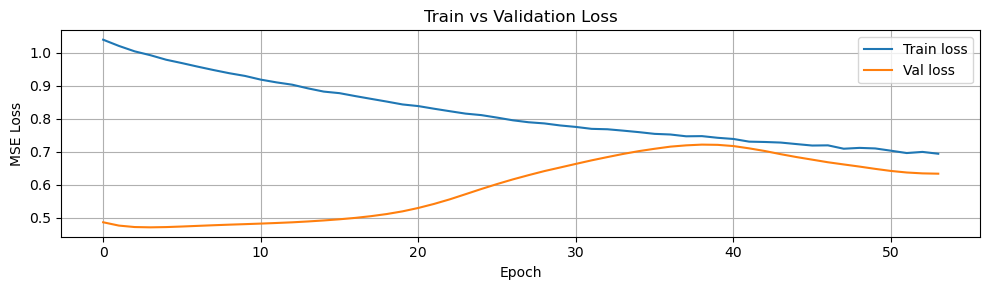

In [115]:
model     = RefinerNet(input_size=22).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn   = nn.MSELoss()

best_val_loss    = float('inf')
best_model_state = None
train_losses, val_losses = [], []
patience, patience_counter = 50, 0

for epoch in range(500):
    model.train()
    X_aug = X_tensor.clone()
    X_aug[:, 0:3]  += torch.randn_like(X_aug[:, 0:3])  * 0.002 
    X_aug[:, 6:9]  += torch.randn_like(X_aug[:, 6:9])  * 0.002  
    X_aug[:, 12:15]+= torch.randn_like(X_aug[:, 12:15])* 0.3   
    X_aug[:, 16:19]*= (torch.rand_like(X_aug[:, 16:19]) > 0.1).float()  
    y_aug = y_tensor + torch.randn_like(y_tensor) * 0.001         

    optimizer.zero_grad()
    #train_loss = loss_fn(model(X_tensor), y_tensor) # without aug just to check
    train_loss = loss_fn(model(X_aug), y_aug)
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(X_val_tensor), y_val_tensor)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if val_loss.item() < best_val_loss:
        best_val_loss    = val_loss.item()
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d}  Train: {train_loss.item():.6f}  Val: {val_loss.item():.6f}")

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch} (val loss not improving for {patience} epochs)")
        break

model.load_state_dict(best_model_state)
print(f"\nBest val loss: {best_val_loss:.6f}")

plt.figure(figsize=(10, 3))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Inference on all frames

In [116]:
model.eval()
features_flat   = features.reshape(-1, 22)
features_scaled = (features_flat - X_mean) / X_std

with torch.no_grad():
    pred_delta_scaled = model(
        torch.tensor(features_scaled, dtype=torch.float32).to(device)
    ).cpu().numpy()

pred_delta = (pred_delta_scaled * y_std + y_mean).reshape(T, N, 3)

X_est_ml = X_filled + pred_delta

## Transformers

### Architecture

In [117]:
#New for transformers
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=32):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return x

In [118]:
WINDOW = 32          
PAD    = WINDOW // 2 

class TrajectoryRefinerTransformer(nn.Module):
    def __init__(self, n_features=22, d_model=64, nhead=4, num_layers=2):
        super().__init__()

        self.input_proj = nn.Linear(n_features, d_model)

        self.pos_encoder = PositionalEncoding(
            d_model=d_model,
            max_len=WINDOW
        )

        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=128,
                dropout=0.1,
                batch_first=True
            ),
            num_layers=num_layers
        )

        self.head = nn.Linear(d_model, 3)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.encoder(x)

        return self.head(x[:, PAD])


class WindowDataset(Dataset):

    def __init__(
        self,
        features,
        targets,
        mask,
        window,
        x_mean,
        x_std,
        y_mean,
        y_std,
        start_frame,
        end_frame
    ):

        self.X = []
        self.y = []

        # ----------------------------------------------------
        # Restrict features to this temporal subset FIRST
        # ----------------------------------------------------

        features_subset = features[start_frame:end_frame]

        # Normalize using TRAIN statistics
        feat_norm = (features_subset - x_mean) / x_std

        # Padding is now applied ONLY inside this temporal subset
        feat_padded = np.pad(
            feat_norm,
            (
                (window // 2, window // 2),
                (0, 0),
                (0, 0)
            ),
            mode="edge"
        )

        # ----------------------------------------------------
        # Build temporal windows
        # ----------------------------------------------------

        for n in range(features.shape[1]):

            # Global frame indices belonging to this mask
            valid_frames = np.where(mask[:, n])[0]

            for t in valid_frames:

                # Safety check
                if not (start_frame <= t < end_frame):
                    continue

                # Convert global frame -> local frame
                local_t = t - start_frame

                # Window constructed ONLY from current subset
                window_features = feat_padded[
                    local_t : local_t + window,
                    n,
                    :
                ]

                self.X.append(window_features)

                self.y.append(
                    (targets[t, n] - y_mean) / y_std
                )

        self.X = torch.tensor(
            np.array(self.X),
            dtype=torch.float32
        )

        self.y = torch.tensor(
            np.array(self.y),
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


### Validation dataset

In [119]:
train_dataset = WindowDataset(
    features=features,
    targets=target_delta,
    mask=train_mask,
    window=WINDOW,
    x_mean=X_mean,
    x_std=X_std,
    y_mean=y_mean,
    y_std=y_std,
    start_frame=0,
    end_frame=train_end
)


val_dataset = WindowDataset(
    features=features,
    targets=target_delta,
    mask=val_mask,
    window=WINDOW,
    x_mean=X_mean,
    x_std=X_std,
    y_mean=y_mean,
    y_std=y_std,
    start_frame=train_end,
    end_frame=val_end
)


test_dataset = WindowDataset(
    features=features,
    targets=target_delta,
    mask=test_mask,
    window=WINDOW,
    x_mean=X_mean,
    x_std=X_std,
    y_mean=y_mean,
    y_std=y_std,
    start_frame=val_end,
    end_frame=T
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)


print(f"Train windows : {len(train_dataset)}")
print(f"Val windows   : {len(val_dataset)}")
print(f"Test windows  : {len(test_dataset)}")

Train windows : 3360
Val windows   : 480
Test windows  : 960


### Train

Epoch    0  Train: 0.998528  Val: 0.593807
Epoch   50  Train: 0.085309  Val: 0.547716

Early stopping at epoch 56

Best epoch: 6

Best val loss: 0.496473


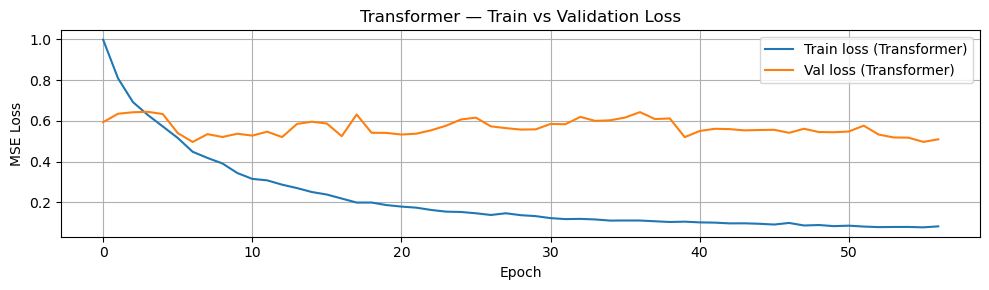

In [120]:
tr_model   = TrajectoryRefinerTransformer(n_features=22).to(device)
tr_optim   = torch.optim.Adam(tr_model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn_tr = nn.MSELoss()
tr_best_epoch = 0

tr_best_val   = float('inf')
tr_best_state = None
tr_train_losses, tr_val_losses = [], []
tr_patience, tr_patience_ctr   = 50, 0

for epoch in range(500):
    tr_model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        xb[:, :, 0:3]   += torch.randn_like(xb[:, :, 0:3])   * 0.002
        xb[:, :, 6:9]   += torch.randn_like(xb[:, :, 6:9])   * 0.002
        xb[:, :, 12:15] += torch.randn_like(xb[:, :, 12:15]) * 0.3
        xb[:, :, 16:19] *= (torch.rand_like(xb[:, :, 16:19]) > 0.1).float()
        yb               += torch.randn_like(yb) * 0.001

        tr_optim.zero_grad()
        loss = loss_fn_tr(tr_model(xb), yb)
        loss.backward()
        tr_optim.step()
        epoch_loss += loss.item() * len(xb)

    tr_model.eval()
    val_loss_sum = 0
    with torch.no_grad():
        for xb_v, yb_v in val_loader:
            xb_v, yb_v = xb_v.to(device), yb_v.to(device)
            val_loss_sum += loss_fn_tr(tr_model(xb_v), yb_v).item() * len(xb_v)

    train_l = epoch_loss   / len(train_dataset)
    val_l   = val_loss_sum / len(val_dataset)
    tr_train_losses.append(train_l)
    tr_val_losses.append(val_l)

    if val_l < tr_best_val:
        tr_best_val   = val_l
        tr_best_epoch = epoch
        tr_best_state = {k: v.clone() for k, v in tr_model.state_dict().items()}
        tr_patience_ctr = 0
    else:
        tr_patience_ctr += 1

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d}  Train: {train_l:.6f}  Val: {val_l:.6f}")

    if tr_patience_ctr >= tr_patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

tr_model.load_state_dict(tr_best_state)
print(f"\nBest epoch: {tr_best_epoch}")
print(f"\nBest val loss: {tr_best_val:.6f}")

plt.figure(figsize=(10, 3))
plt.plot(tr_train_losses, label='Train loss (Transformer)')
plt.plot(tr_val_losses,   label='Val loss (Transformer)')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Transformer — Train vs Validation Loss')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### Inference

In [121]:
def predict_transformer_subset(
    model,
    features,
    start_frame,
    end_frame,
    window,
    x_mean,
    x_std,
    y_mean,
    y_std,
    device
):
    pad = window // 2

    # Take only this temporal subset
    features_subset = features[start_frame:end_frame]

    # Normalize with TRAIN statistics
    feat_norm = (features_subset - x_mean) / x_std

    # Pad only inside this subset
    feat_padded = np.pad(
        feat_norm,
        ((pad, pad), (0, 0), (0, 0)),
        mode="edge"
    )

    subset_length = end_frame - start_frame

    pred_delta = np.zeros((subset_length, features.shape[1], 3))

    model.eval()

    with torch.no_grad():

        for n in range(features.shape[1]):

            windows = np.stack(
                [
                    feat_padded[t:t+window, n, :]
                    for t in range(subset_length)
                ],
                axis=0
            )

            windows_t = torch.tensor(
                windows,
                dtype=torch.float32
            ).to(device)

            pred_scaled = model(windows_t).cpu().numpy()

            pred_delta[:, n, :] = (
                pred_scaled * y_std + y_mean
            )

    return pred_delta

In [122]:
pred_delta_train = predict_transformer_subset(
    tr_model,
    features,
    start_frame=0,
    end_frame=train_end,
    window=WINDOW,
    x_mean=X_mean,
    x_std=X_std,
    y_mean=y_mean,
    y_std=y_std,
    device=device
)

pred_delta_val = predict_transformer_subset(
    tr_model,
    features,
    start_frame=train_end,
    end_frame=val_end,
    window=WINDOW,
    x_mean=X_mean,
    x_std=X_std,
    y_mean=y_mean,
    y_std=y_std,
    device=device
)

pred_delta_test = predict_transformer_subset(
    tr_model,
    features,
    start_frame=val_end,
    end_frame=T,
    window=WINDOW,
    x_mean=X_mean,
    x_std=X_std,
    y_mean=y_mean,
    y_std=y_std,
    device=device
)

In [123]:
pred_delta_tr = np.zeros((T, N, 3))

pred_delta_tr[:train_end] = pred_delta_train
pred_delta_tr[train_end:val_end] = pred_delta_val
pred_delta_tr[val_end:] = pred_delta_test

X_est_ml_tr = X_filled + pred_delta_tr

# Evaluation

In [124]:
geo_error     = np.linalg.norm(X_est_geo[test_tri_mask] - pos3d_gt[test_tri_mask], axis=1).mean()
ml_error_tri  = np.linalg.norm(X_est_ml[test_tri_mask]  - pos3d_gt[test_tri_mask], axis=1).mean()
tr_error_tri  = np.linalg.norm(X_est_ml_tr[test_tri_mask] - pos3d_gt[test_tri_mask], axis=1).mean()

interp_error  = np.linalg.norm(X_filled[test_all_mask]    - pos3d_gt[test_all_mask], axis=1).mean()
ml_error_all  = np.linalg.norm(X_est_ml[test_all_mask]    - pos3d_gt[test_all_mask], axis=1).mean()
tr_error_all  = np.linalg.norm(X_est_ml_tr[test_all_mask] - pos3d_gt[test_all_mask], axis=1).mean()

print("FINAL PERFORMANCE (TEST SET ONLY)")
print(f"\n[Goal 1 — Accuracy on triangulated frames]")
print(f"  Geometric Triangulation : {geo_error:.4f} m")
print(f"  MLP Refined (RefinerNet): {ml_error_tri:.4f} m  ({(geo_error-ml_error_tri)/geo_error*100:+.2f}%)")
print(f"  Transformer Refined     : {tr_error_tri:.4f} m  ({(geo_error-tr_error_tri)/geo_error*100:+.2f}%)")

print(f"\n[Goal 2 — Gap filling on ALL frames (incl. occluded)]")
print(f"  Naive interpolation     : {interp_error:.4f} m")
print(f"  MLP gap filling         : {ml_error_all:.4f} m  ({(interp_error-ml_error_all)/interp_error*100:+.2f}%)")
print(f"  Transformer gap filling : {tr_error_all:.4f} m  ({(interp_error-tr_error_all)/interp_error*100:+.2f}%)")


FINAL PERFORMANCE (TEST SET ONLY)

[Goal 1 — Accuracy on triangulated frames]
  Geometric Triangulation : 0.0115 m
  MLP Refined (RefinerNet): 0.0113 m  (+1.99%)
  Transformer Refined     : 0.0096 m  (+16.86%)

[Goal 2 — Gap filling on ALL frames (incl. occluded)]
  Naive interpolation     : 0.0122 m
  MLP gap filling         : 0.0124 m  (-1.61%)
  Transformer gap filling : 0.0120 m  (+1.90%)


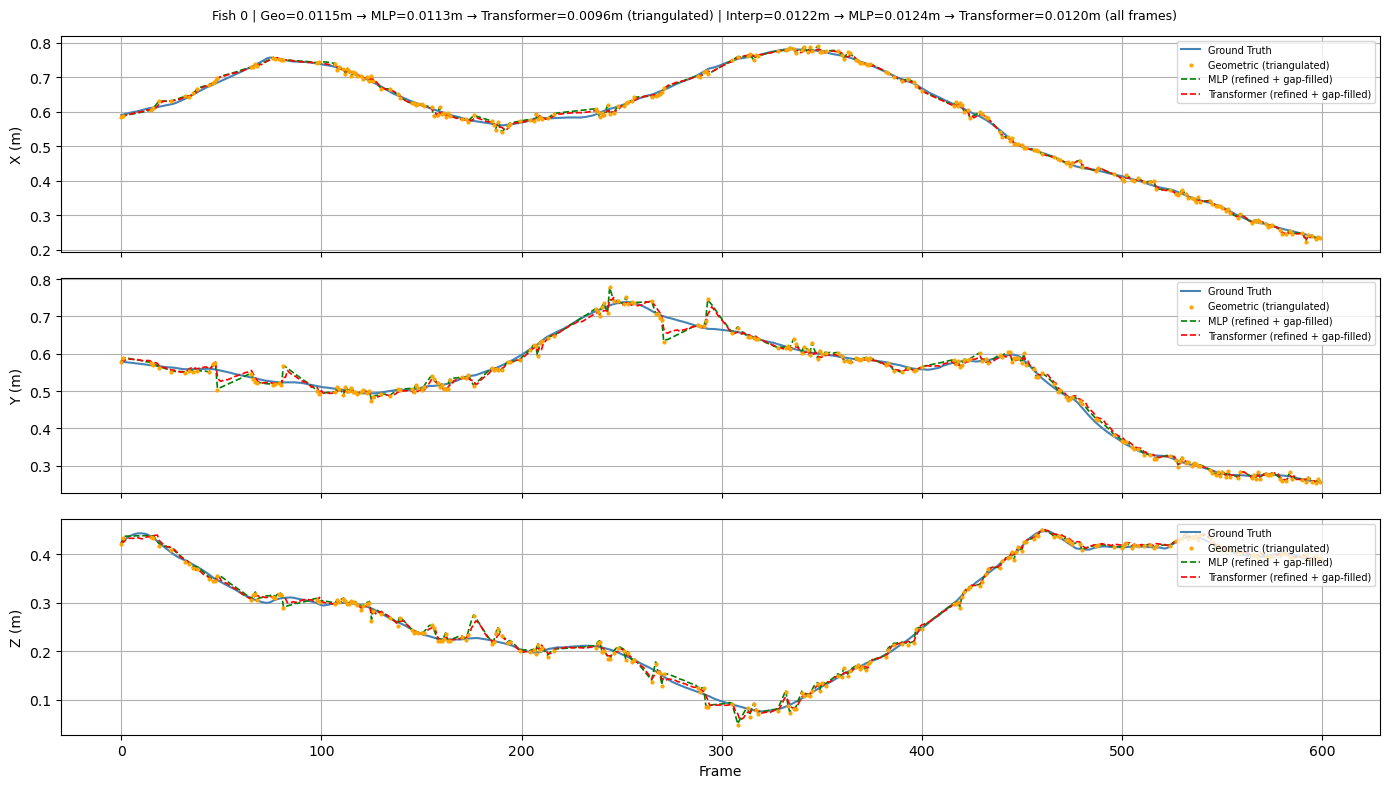

In [125]:
interp_error_all = np.linalg.norm(
    X_filled[test_all_mask] - pos3d_gt[test_all_mask], axis=1
).mean()

fish_idx = 0
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
labels = ['X', 'Y', 'Z']

for d, ax in enumerate(axes):
    ax.plot(pos3d_gt[:, fish_idx, d],
            label='Ground Truth', color='steelblue', linewidth=1.5)
    ax.scatter(np.where(np.isfinite(X_est_geo[:, fish_idx, d]))[0],
               X_est_geo[np.isfinite(X_est_geo[:, fish_idx, d]), fish_idx, d],
               s=4, color='orange', label='Geometric (triangulated)', zorder=3)
    ax.plot(X_est_ml[:, fish_idx, d],
            '--', color='green', linewidth=1.2, label='MLP (refined + gap-filled)')
    ax.plot(X_est_ml_tr[:, fish_idx, d],
            '--', color='red', linewidth=1.2, label='Transformer (refined + gap-filled)')
    ax.set_ylabel(f'{labels[d]} (m)')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True)

axes[-1].set_xlabel('Frame')
fig.suptitle(
    f'Fish {fish_idx} | Geo={geo_error:.4f}m → MLP={ml_error_tri:.4f}m → Transformer={tr_error_tri:.4f}m (triangulated) | '
    f'Interp={interp_error_all:.4f}m → MLP={ml_error_all:.4f}m → Transformer={tr_error_all:.4f}m (all frames)',
    fontsize=9
)
plt.tight_layout()
plt.show()

# Creation Images

In [126]:
# ============================================================
# FIND FRAMES WHERE TRANSFORMER POSITIONS ARE BETTER THAN MLP
# ============================================================

valid_gt = np.isfinite(pos3d_gt).all(axis=2)
valid_mlp = np.isfinite(X_est_ml).all(axis=2)
valid_transformer = np.isfinite(X_est_ml_tr).all(axis=2)

T = pos3d_gt.shape[0]

mlp_error_per_frame = np.full(T, np.nan)
transformer_error_per_frame = np.full(T, np.nan)
common_fish_count = np.zeros(T, dtype=int)

for frame in range(T):

    # Only fish available in GT, MLP, and Transformer
    common_valid = (
        valid_gt[frame]
        & valid_mlp[frame]
        & valid_transformer[frame]
    )

    common_fish_count[frame] = common_valid.sum()

    if common_fish_count[frame] > 0:

        mlp_distances = np.linalg.norm(
            X_est_ml[frame, common_valid]
            - pos3d_gt[frame, common_valid],
            axis=1
        )

        transformer_distances = np.linalg.norm(
            X_est_ml_tr[frame, common_valid]
            - pos3d_gt[frame, common_valid],
            axis=1
        )

        mlp_error_per_frame[frame] = np.mean(mlp_distances)

        transformer_error_per_frame[frame] = np.mean(
            transformer_distances
        )


# Positive value means Transformer is better
absolute_improvement = (
    mlp_error_per_frame
    - transformer_error_per_frame
)

relative_improvement = (
    absolute_improvement
    / mlp_error_per_frame
    * 100
)

# Require at least 3 common fish to avoid selecting
# a frame based on only one fish
candidate_mask = (
    np.isfinite(relative_improvement)
    & (common_fish_count >= 3)
    & (relative_improvement > 0)
)

frames_transformer_better = np.where(candidate_mask)[0]

# Sort by greatest percentage improvement
frames_transformer_better = frames_transformer_better[
    np.argsort(
        relative_improvement[frames_transformer_better]
    )[::-1]
]

print(
    "\nFrames where Transformer has lower positional error than MLP:"
)
print("-" * 100)

for frame in frames_transformer_better[:30]:

    print(
        f"Frame {frame:4d} | "
        f"Common fish: {common_fish_count[frame]} | "
        f"MLP error: {mlp_error_per_frame[frame]:.5f} m | "
        f"Transformer error: "
        f"{transformer_error_per_frame[frame]:.5f} m | "
        f"Improvement: {relative_improvement[frame]:.2f}%"
    )


Frames where Transformer has lower positional error than MLP:
----------------------------------------------------------------------------------------------------
Frame  154 | Common fish: 8 | MLP error: 0.02222 m | Transformer error: 0.00913 m | Improvement: 58.93%
Frame  174 | Common fish: 8 | MLP error: 0.02345 m | Transformer error: 0.00984 m | Improvement: 58.05%
Frame  187 | Common fish: 8 | MLP error: 0.02106 m | Transformer error: 0.00890 m | Improvement: 57.72%
Frame  152 | Common fish: 8 | MLP error: 0.01682 m | Transformer error: 0.00760 m | Improvement: 54.81%
Frame  155 | Common fish: 8 | MLP error: 0.02429 m | Transformer error: 0.01099 m | Improvement: 54.77%
Frame  188 | Common fish: 8 | MLP error: 0.02033 m | Transformer error: 0.00924 m | Improvement: 54.55%
Frame  183 | Common fish: 8 | MLP error: 0.02726 m | Transformer error: 0.01239 m | Improvement: 54.54%
Frame  157 | Common fish: 8 | MLP error: 0.02288 m | Transformer error: 0.01046 m | Improvement: 54.29%
Fram

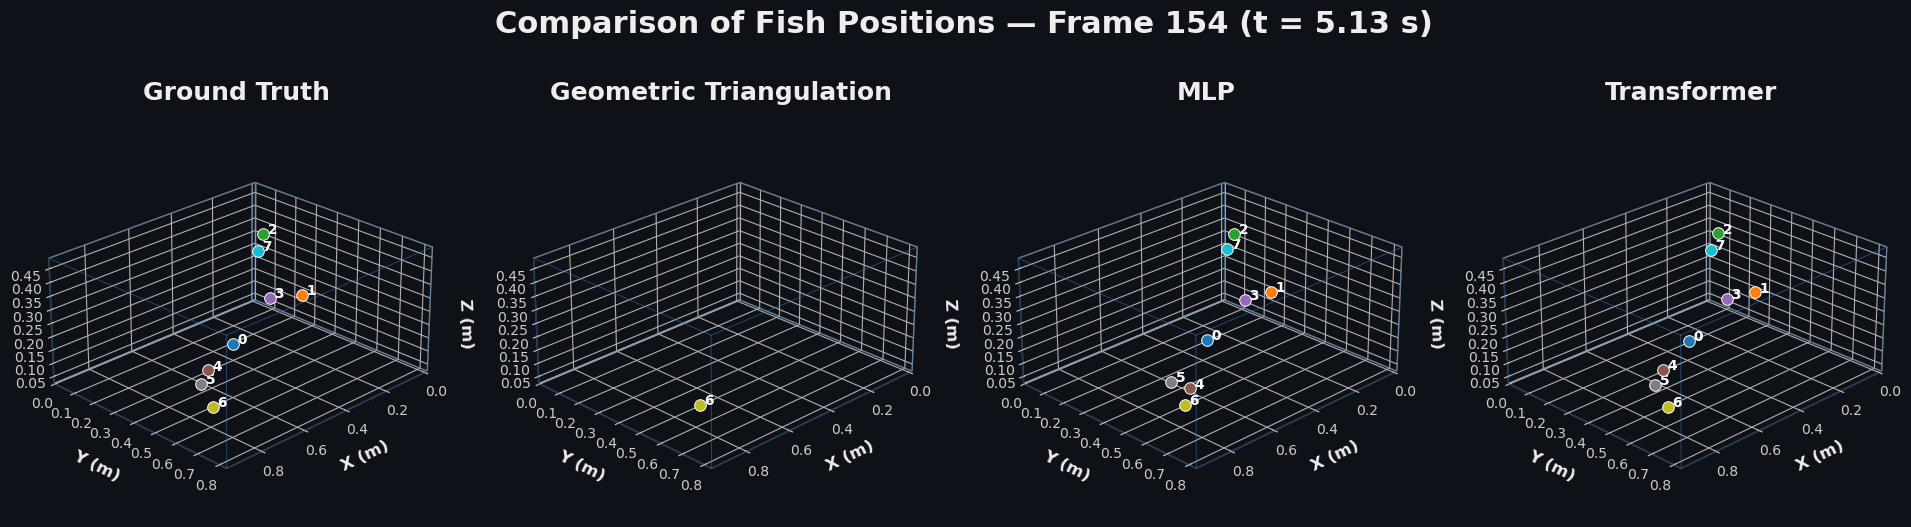

Saved figure: /Users/marilb/Desktop/THESIS/VIDEO_CREATION/outputs/figures_results/comparison_frame_154.png


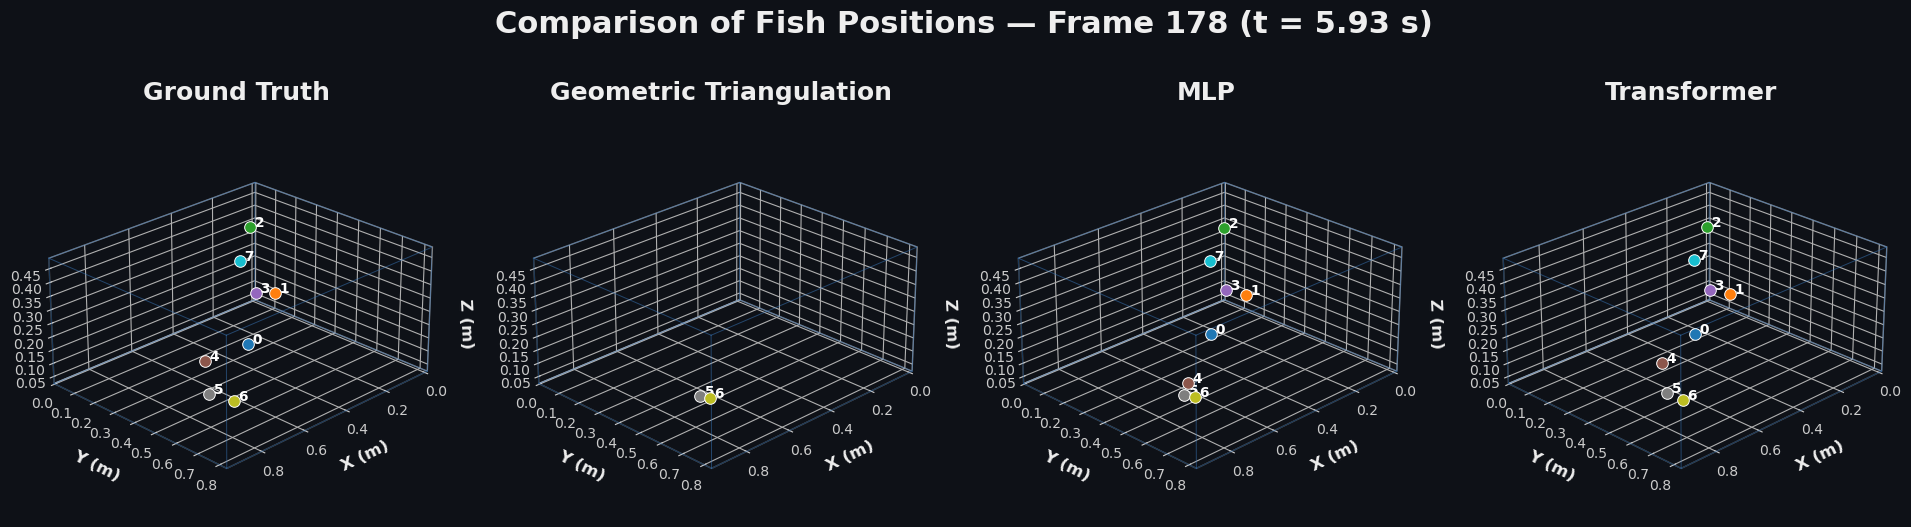

Saved figure: /Users/marilb/Desktop/THESIS/VIDEO_CREATION/outputs/figures_results/comparison_frame_178.png


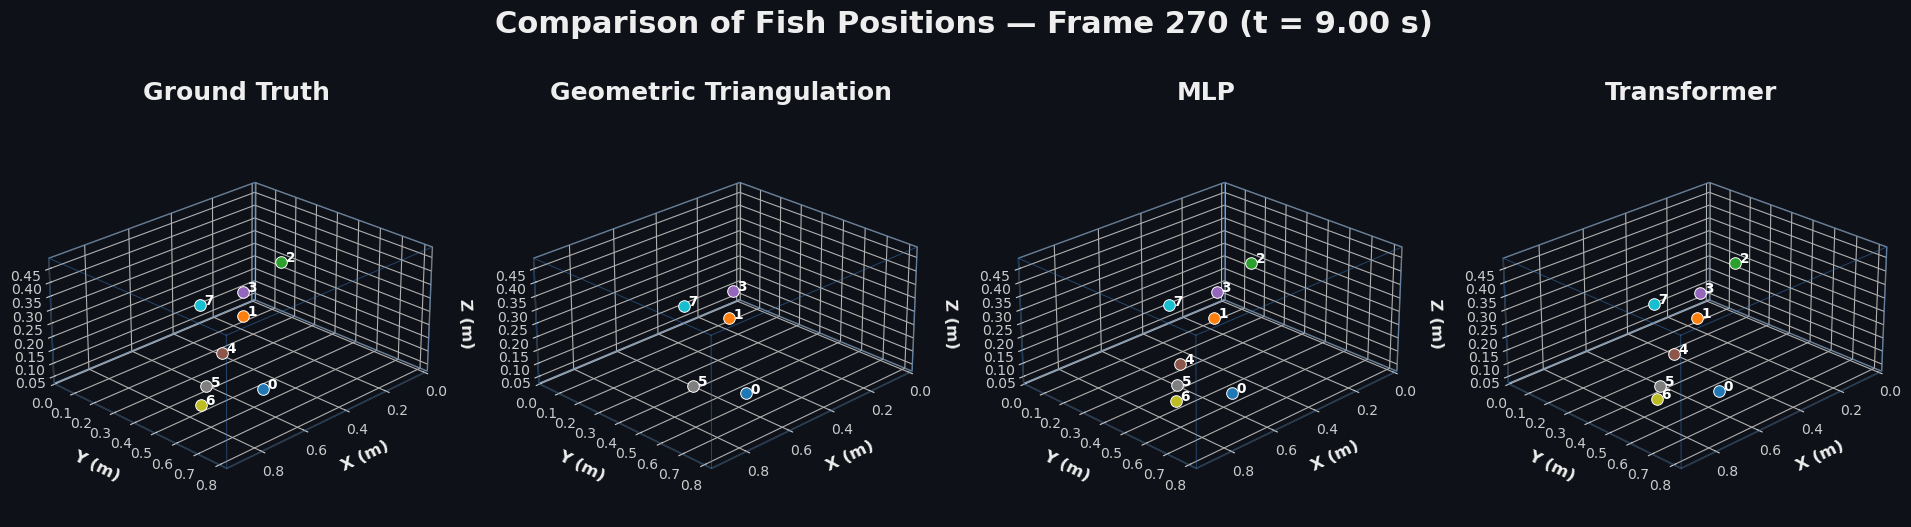

Saved figure: /Users/marilb/Desktop/THESIS/VIDEO_CREATION/outputs/figures_results/comparison_frame_270.png


In [ ]:
# ============================================================
# SETTINGS
# ============================================================

frames_to_plot = [154, 178, 270]

titles = [
    "Ground Truth",
    "Geometric Triangulation",
    "MLP",
    "Transformer"
]

positions = [
    pos3d_gt,
    X_est_geo,
    X_est_ml,
    X_est_ml_tr
]

N = pos3d_gt.shape[1]
T = pos3d_gt.shape[0]

fish_colors = plt.cm.tab10(np.linspace(0, 1, N))

OUTPUT_DIR = os.path.join(BASE_DIR, "figures_results")
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# CHECK FRAMES
# ============================================================

frames_to_plot = [
    frame for frame in frames_to_plot
    if 0 <= frame < T
]

if len(frames_to_plot) == 0:
    raise ValueError("None of the selected frames is valid.")


# ============================================================
# COMPUTE COMMON 3D LIMITS FROM GROUND TRUTH
# ============================================================

valid_gt = pos3d_gt[np.isfinite(pos3d_gt).all(axis=2)]

if valid_gt.size == 0:
    raise ValueError("Ground-truth coordinates contain no valid 3D points.")

x_min, y_min, z_min = np.min(valid_gt, axis=0)
x_max, y_max, z_max = np.max(valid_gt, axis=0)

# Small margins
x_margin = max((x_max - x_min) * 0.08, 0.02)
y_margin = max((y_max - y_min) * 0.08, 0.02)
z_margin = max((z_max - z_min) * 0.08, 0.02)

x_lim = (x_min - x_margin, x_max + x_margin)
y_lim = (y_min - y_margin, y_max + y_margin)
z_lim = (max(0, z_min - z_margin), z_max + z_margin)


# ============================================================
# FUNCTION TO DRAW THE TANK-LIKE BOX
# ============================================================

def draw_box(ax, x_lim, y_lim, z_lim):
    x0, x1 = x_lim
    y0, y1 = y_lim
    z0, z1 = z_lim

    edges = [
        [(x0, y0, z0), (x1, y0, z0)],
        [(x0, y1, z0), (x1, y1, z0)],
        [(x0, y0, z1), (x1, y0, z1)],
        [(x0, y1, z1), (x1, y1, z1)],

        [(x0, y0, z0), (x0, y1, z0)],
        [(x1, y0, z0), (x1, y1, z0)],
        [(x0, y0, z1), (x0, y1, z1)],
        [(x1, y0, z1), (x1, y1, z1)],

        [(x0, y0, z0), (x0, y0, z1)],
        [(x1, y0, z0), (x1, y0, z1)],
        [(x0, y1, z0), (x0, y1, z1)],
        [(x1, y1, z0), (x1, y1, z1)]
    ]

    for edge in edges:
        xs, ys, zs = zip(*edge)

        ax.plot(
            xs,
            ys,
            zs,
            color="#3a7abf",
            linewidth=0.7,
            alpha=0.5
        )


# ============================================================
# CREATE ONE FIGURE FOR EACH FRAME
# ============================================================

# Font sizes
TITLE_SIZE = 18
AXIS_LABEL_SIZE = 12
TICK_SIZE = 10
FISH_LABEL_SIZE = 10
SUPTITLE_SIZE = 22

for frame in frames_to_plot:

    # One row with four methods
    fig = plt.figure(figsize=(20, 5.5))
    fig.patch.set_facecolor("#0e1117")

    for col_idx, (title, pos) in enumerate(zip(titles, positions)):

        ax = fig.add_subplot(
            1,
            4,
            col_idx + 1,
            projection="3d"
        )

        ax.set_facecolor("#0e1117")

        # Increase tick-label size
        ax.tick_params(
            axis="both",
            colors="#cccccc",
            labelsize=TICK_SIZE,
            pad=1
        )

        draw_box(
            ax,
            x_lim,
            y_lim,
            z_lim
        )

        # Plot each fish
        for fish_idx in range(N):

            point = pos[frame, fish_idx]

            if np.isfinite(point).all():

                ax.scatter(
                    point[0],
                    point[1],
                    point[2],
                    s=70,
                    color=fish_colors[fish_idx],
                    edgecolor="white",
                    linewidth=0.7,
                    depthshade=True
                )

                ax.text(
                    point[0],
                    point[1],
                    point[2],
                    f" {fish_idx}",
                    color="white",
                    fontsize=FISH_LABEL_SIZE,
                    fontweight="bold"
                )

        # Same limits for all methods
        ax.set_xlim(*x_lim)
        ax.set_ylim(*y_lim)
        ax.set_zlim(*z_lim)

        ax.set_box_aspect((
            x_lim[1] - x_lim[0],
            y_lim[1] - y_lim[0],
            z_lim[1] - z_lim[0]
        ))

        ax.view_init(
            elev=25,
            azim=45
        )

        # Axis labels
        ax.set_xlabel(
            "X (m)",
            color="#eeeeee",
            fontsize=AXIS_LABEL_SIZE,
            fontweight="bold",
            labelpad=6
        )

        ax.set_ylabel(
            "Y (m)",
            color="#eeeeee",
            fontsize=AXIS_LABEL_SIZE,
            fontweight="bold",
            labelpad=6
        )

        ax.set_zlabel(
            "Z (m)",
            color="#eeeeee",
            fontsize=AXIS_LABEL_SIZE,
            fontweight="bold",
            labelpad=6
        )

        # Transparent panes
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False

        # Method title
        ax.set_title(
            title,
            color="#eeeeee",
            fontsize=TITLE_SIZE,
            fontweight="bold",
            pad=18
        )

    # Main title for each frame
    fig.suptitle(
        f"Comparison of Fish Positions — Frame {frame} "
        f"(t = {frame / 30:.2f} s)",
        color="#eeeeee",
        fontsize=SUPTITLE_SIZE,
        fontweight="bold",
        y=0.98
    )

    plt.tight_layout(
        rect=[0.01, 0.02, 0.99, 0.90],
        pad=1.5,
        w_pad=1.5
    )

    # Separate filename for each frame
    output_path = os.path.join(
        OUTPUT_DIR,
        f"comparison_frame_{frame}.png"
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )

    plt.show()
    plt.close(fig)

    print(f"Saved figure: {output_path}")

# Multiple Trainings

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Fixed baselines

In [104]:
geo_error = np.linalg.norm(
    X_est_geo[test_tri_mask] - pos3d_gt[test_tri_mask], axis=1
).mean()

interp_error = np.linalg.norm(
    X_filled[test_all_mask] - pos3d_gt[test_all_mask], axis=1
).mean()

print("Fixed baselines")
print(f"Geometric triangulation: {geo_error:.4f} m")
print(f"Naive interpolation:     {interp_error:.4f} m")

Fixed baselines
Geometric triangulation: 0.0115 m
Naive interpolation:     0.0122 m


## Training MLP per seed

In [105]:
def train_mlp_one_seed(seed):
    set_seed(seed)

    model = RefinerNet(input_size=22).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()

    best_val_loss = float("inf")
    best_model_state = None
    patience = 50
    patience_counter = 0

    for epoch in range(500):
        model.train()

        X_aug = X_tensor.clone()
        X_aug[:, 0:3] += torch.randn_like(X_aug[:, 0:3]) * 0.002
        X_aug[:, 6:9] += torch.randn_like(X_aug[:, 6:9]) * 0.002
        X_aug[:, 12:15] += torch.randn_like(X_aug[:, 12:15]) * 0.3
        X_aug[:, 16:19] *= (torch.rand_like(X_aug[:, 16:19]) > 0.1).float()

        y_aug = y_tensor + torch.randn_like(y_tensor) * 0.001

        optimizer.zero_grad()
        train_loss = loss_fn(model(X_aug), y_aug)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_tensor), y_val_tensor)

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_model_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    model.load_state_dict({
        k: v.to(device)
        for k, v in best_model_state.items()
    })

    model.eval()

    features_flat = features.reshape(-1, 22)
    features_scaled = (features_flat - X_mean) / X_std

    with torch.no_grad():
        pred_delta_scaled = model(
            torch.tensor(features_scaled, dtype=torch.float32).to(device)
        ).cpu().numpy()

    pred_delta = (pred_delta_scaled * y_std + y_mean).reshape(T, N, 3)
    X_est_ml_seed = X_filled + pred_delta

    ml_error_tri = np.linalg.norm(
        X_est_ml_seed[test_tri_mask] - pos3d_gt[test_tri_mask], axis=1
    ).mean()

    ml_error_all = np.linalg.norm(
        X_est_ml_seed[test_all_mask] - pos3d_gt[test_all_mask], axis=1
    ).mean()

    return ml_error_tri, ml_error_all, best_val_loss

## Training transformer per seed

In [ ]:
def predict_transformer_subset(
    model,
    features,
    start_frame,
    end_frame,
    window,
    x_mean,
    x_std,
    y_mean,
    y_std,
    device
):
    pad = window // 2

    # Use only the frames belonging to this temporal subset
    features_subset = features[start_frame:end_frame]

    # Normalize using training statistics
    feat_norm = (features_subset - x_mean) / x_std

    # Padding only inside this subset
    feat_padded = np.pad(
        feat_norm,
        ((pad, pad), (0, 0), (0, 0)),
        mode="edge"
    )

    subset_length = end_frame - start_frame
    pred_delta = np.zeros((subset_length, features.shape[1], 3))

    model.eval()

    with torch.no_grad():
        for n in range(features.shape[1]):

            windows = np.stack(
                [
                    feat_padded[t:t+window, n, :]
                    for t in range(subset_length)
                ],
                axis=0
            )

            windows_t = torch.tensor(
                windows,
                dtype=torch.float32
            ).to(device)

            pred_scaled = model(windows_t).cpu().numpy()

            pred_delta[:, n, :] = (
                pred_scaled * y_std + y_mean
            )

    return pred_delta

def train_transformer_one_seed(seed):
    set_seed(seed)

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=256,
        shuffle=True,
        generator=generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=256,
        shuffle=False
    )

    tr_model = TrajectoryRefinerTransformer(n_features=22).to(device)
    tr_optim = torch.optim.Adam(tr_model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn_tr = nn.MSELoss()

    tr_best_val = float("inf")
    tr_best_state = None
    tr_patience = 50
    tr_patience_ctr = 0

    for epoch in range(500):
        tr_model.train()
        epoch_loss = 0

        for xb, yb in train_loader:
            xb = xb.to(device).clone()
            yb = yb.to(device).clone()

            xb[:, :, 0:3] += torch.randn_like(xb[:, :, 0:3]) * 0.002
            xb[:, :, 6:9] += torch.randn_like(xb[:, :, 6:9]) * 0.002
            xb[:, :, 12:15] += torch.randn_like(xb[:, :, 12:15]) * 0.3
            xb[:, :, 16:19] *= (torch.rand_like(xb[:, :, 16:19]) > 0.1).float()

            yb += torch.randn_like(yb) * 0.001

            tr_optim.zero_grad()
            loss = loss_fn_tr(tr_model(xb), yb)
            loss.backward()
            tr_optim.step()

            epoch_loss += loss.item() * len(xb)

        tr_model.eval()
        val_loss_sum = 0

        with torch.no_grad():
            for xb_v, yb_v in val_loader:
                xb_v = xb_v.to(device)
                yb_v = yb_v.to(device)

                val_loss_sum += loss_fn_tr(
                    tr_model(xb_v), yb_v
                ).item() * len(xb_v)

        val_l = val_loss_sum / len(val_dataset)

        if val_l < tr_best_val:
            tr_best_val = val_l
            tr_best_state = {
                k: v.detach().cpu().clone()
                for k, v in tr_model.state_dict().items()
            }
            tr_patience_ctr = 0
        else:
            tr_patience_ctr += 1

        if tr_patience_ctr >= tr_patience:
            break

    tr_model.load_state_dict({
        k: v.to(device)
        for k, v in tr_best_state.items()
    })

    tr_model.eval()

    # ---------------------------------------------------------
    # INFERENCE WITHOUT CROSSING TEMPORAL SPLIT BOUNDARIES
    # ---------------------------------------------------------

    pred_delta_train = predict_transformer_subset(
        tr_model,
        features,
        start_frame=0,
        end_frame=train_end,
        window=WINDOW,
        x_mean=X_mean,
        x_std=X_std,
        y_mean=y_mean,
        y_std=y_std,
        device=device
    )

    pred_delta_val = predict_transformer_subset(
        tr_model,
        features,
        start_frame=train_end,
        end_frame=val_end,
        window=WINDOW,
        x_mean=X_mean,
        x_std=X_std,
        y_mean=y_mean,
        y_std=y_std,
        device=device
    )

    pred_delta_test = predict_transformer_subset(
        tr_model,
        features,
        start_frame=val_end,
        end_frame=T,
        window=WINDOW,
        x_mean=X_mean,
        x_std=X_std,
        y_mean=y_mean,
        y_std=y_std,
        device=device
    )

    # Reconstruct complete prediction array
    pred_delta_tr = np.zeros((T, N, 3))

    pred_delta_tr[:train_end] = pred_delta_train
    pred_delta_tr[train_end:val_end] = pred_delta_val
    pred_delta_tr[val_end:] = pred_delta_test

    X_est_tr_seed = X_filled + pred_delta_tr

    tr_error_tri = np.linalg.norm(
        X_est_tr_seed[test_tri_mask] - pos3d_gt[test_tri_mask], axis=1
    ).mean()

    tr_error_all = np.linalg.norm(
        X_est_tr_seed[test_all_mask] - pos3d_gt[test_all_mask], axis=1
    ).mean()

    return tr_error_tri, tr_error_all, tr_best_val

## Running 30 seeds

In [107]:
seeds = list(range(30))
results = []

for seed in seeds:
    print(f"\nRunning seed {seed}")

    ml_error_tri, ml_error_all, ml_val_loss = train_mlp_one_seed(seed)
    tr_error_tri, tr_error_all, tr_val_loss = train_transformer_one_seed(seed)

    results.append({
        "seed": seed,

        "geo_error": geo_error,
        "interp_error": interp_error,

        "ml_error_tri": ml_error_tri,
        "tr_error_tri": tr_error_tri,

        "ml_error_all": ml_error_all,
        "tr_error_all": tr_error_all,

        "ml_val_loss": ml_val_loss,
        "tr_val_loss": tr_val_loss
    })

results_df = pd.DataFrame(results)
results_df.to_csv("results_30_seeds.csv", index=False)

results_df


Running seed 0

Running seed 1

Running seed 2

Running seed 3

Running seed 4

Running seed 5

Running seed 6

Running seed 7

Running seed 8

Running seed 9

Running seed 10

Running seed 11

Running seed 12

Running seed 13

Running seed 14

Running seed 15

Running seed 16

Running seed 17

Running seed 18

Running seed 19

Running seed 20

Running seed 21

Running seed 22

Running seed 23

Running seed 24

Running seed 25

Running seed 26

Running seed 27

Running seed 28

Running seed 29


,seed,geo_error,interp_error,ml_error_tri,tr_error_tri,ml_error_all,tr_error_all,ml_val_loss,tr_val_loss
0,0,0.011487,0.012193,0.011119,0.007754,0.012226,0.010095,0.466732,0.378332
1,1,0.011487,0.012193,0.011973,0.008573,0.012629,0.010409,0.508184,0.434303
2,2,0.011487,0.012193,0.011976,0.007860,0.012874,0.010345,0.509711,0.380047
3,3,0.011487,0.012193,0.012200,0.008427,0.013010,0.010872,0.501004,0.406446
4,4,0.011487,0.012193,0.011117,0.008382,0.012423,0.010959,0.527825,0.339501
5,5,0.011487,0.012193,0.012549,0.007306,0.013356,0.010348,0.546003,0.418522
6,6,0.011487,0.012193,0.011577,0.007152,0.012525,0.010235,0.497935,0.358722
7,7,0.011487,0.012193,0.011552,0.008453,0.012716,0.010444,0.486583,0.339534
8,8,0.011487,0.012193,0.012127,0.008554,0.013056,0.011249,0.515230,0.334475
9,9,0.011487,0.012193,0.011593,0.008363,0.012764,0.011395,0.501958,0.408202


## Tables for comparison

### Goal 1

In [108]:
goal1_summary = pd.DataFrame({
    "Method": [
        "Geometric Triangulation",
        "MLP Refined",
        "Transformer Refined"
    ],
    "Mean Error (m)": [
        geo_error,
        results_df["ml_error_tri"].mean(),
        results_df["tr_error_tri"].mean()
    ],
    "Std Error (m)": [
        np.nan,
        results_df["ml_error_tri"].std(),
        results_df["tr_error_tri"].std()
    ]
})

goal1_summary["Improvement over baseline (%)"] = (
    (geo_error - goal1_summary["Mean Error (m)"]) / geo_error
) * 100

goal1_summary["Mean ± Std (m)"] = goal1_summary.apply(
    lambda row: f"{row['Mean Error (m)']:.4f}"
    if pd.isna(row["Std Error (m)"])
    else f"{row['Mean Error (m)']:.4f} ± {row['Std Error (m)']:.4f}",
    axis=1
)

goal1_final = goal1_summary[
    ["Method", "Mean ± Std (m)", "Improvement over baseline (%)"]
]

goal1_final.to_csv("goal1_final.csv", index=False)

goal1_final

,Method,Mean ± Std (m),Improvement over baseline (%)
0,Geometric Triangulation,0.0115,0.000000
1,MLP Refined,0.0117 ± 0.0004,-1.752060
2,Transformer Refined,0.0086 ± 0.0010,24.984118


### Goal 2

In [109]:
goal2_summary = pd.DataFrame({
    "Method": [
        "Naive Interpolation",
        "MLP Gap Filling",
        "Transformer Gap Filling"
    ],
    "Mean Error (m)": [
        interp_error,
        results_df["ml_error_all"].mean(),
        results_df["tr_error_all"].mean()
    ],
    "Std Error (m)": [
        np.nan,
        results_df["ml_error_all"].std(),
        results_df["tr_error_all"].std()
    ]
})

goal2_summary["Improvement over baseline (%)"] = (
    (interp_error - goal2_summary["Mean Error (m)"]) / interp_error
) * 100

goal2_summary["Mean ± Std (m)"] = goal2_summary.apply(
    lambda row: f"{row['Mean Error (m)']:.4f}"
    if pd.isna(row["Std Error (m)"])
    else f"{row['Mean Error (m)']:.4f} ± {row['Std Error (m)']:.4f}",
    axis=1
)

goal2_final = goal2_summary[
    ["Method", "Mean ± Std (m)", "Improvement over baseline (%)"]
]

goal2_final.to_csv("goal2_final.csv", index=False)

goal2_final

,Method,Mean ± Std (m),Improvement over baseline (%)
0,Naive Interpolation,0.0122,0.000000
1,MLP Gap Filling,0.0127 ± 0.0003,-4.367506
2,Transformer Gap Filling,0.0113 ± 0.0011,7.457164


## Visualization

/var/folders/7k/_hl370j50qj3jp733l0v5zx00000gn/T/ipykernel_47260/1565799386.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


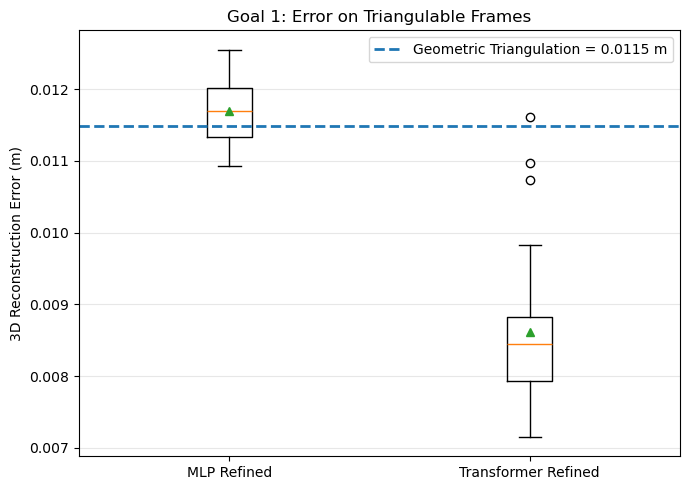

/var/folders/7k/_hl370j50qj3jp733l0v5zx00000gn/T/ipykernel_47260/1565799386.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


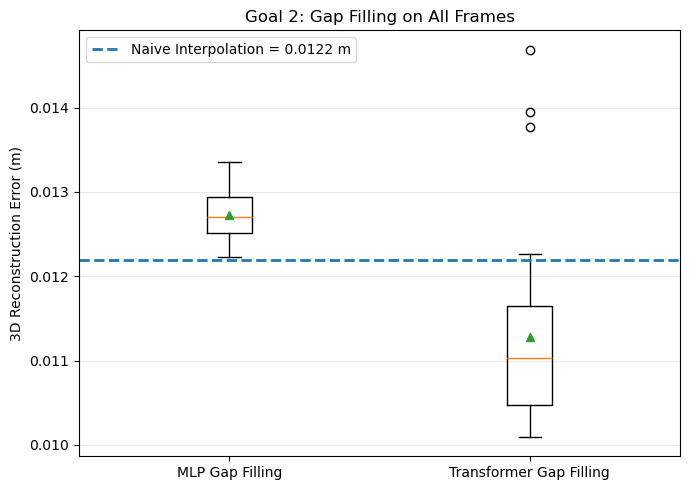

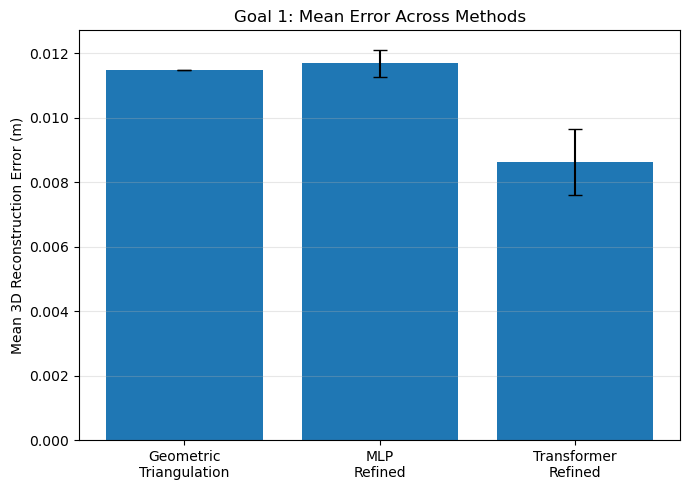

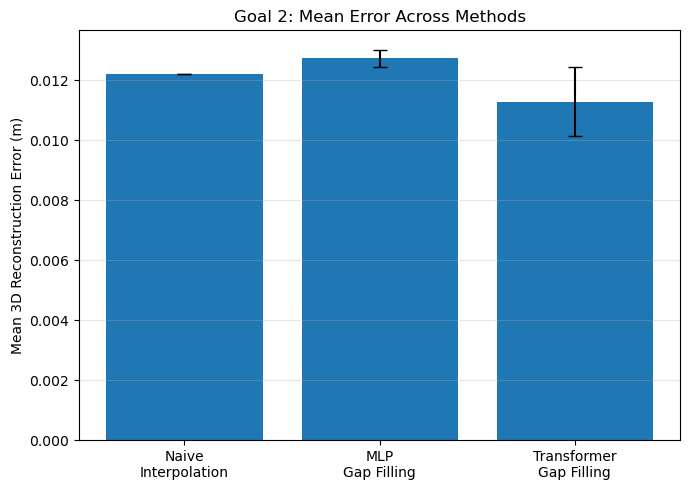

In [ ]:
# Load results
#AJUSTAR AQUI PRA NAO PEGAR DO CSV E SIM DO QUE TA ACIMA
results_df = pd.read_csv("results_30_seeds.csv")

# Fixed baselines
geo_error = results_df["geo_error"].iloc[0]
interp_error = results_df["interp_error"].iloc[0]

# -----------------------------
# Goal 1 Boxplot
# -----------------------------
plt.figure(figsize=(7, 5))

data_goal1 = [
    results_df["ml_error_tri"],
    results_df["tr_error_tri"]
]

plt.boxplot(
    data_goal1,
    labels=["MLP Refined", "Transformer Refined"],
    showmeans=True
)

plt.axhline(
    geo_error,
    linestyle="--",
    linewidth=2,
    label=f"Geometric Triangulation = {geo_error:.4f} m"
)

plt.ylabel("3D Reconstruction Error (m)")
plt.title("Goal 1: Error on Triangulable Frames")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("goal1_boxplot.png", dpi=300)
plt.show()


# -----------------------------
# Goal 2 Boxplot
# -----------------------------
plt.figure(figsize=(7, 5))

data_goal2 = [
    results_df["ml_error_all"],
    results_df["tr_error_all"]
]

plt.boxplot(
    data_goal2,
    labels=["MLP Gap Filling", "Transformer Gap Filling"],
    showmeans=True
)

plt.axhline(
    interp_error,
    linestyle="--",
    linewidth=2,
    label=f"Naive Interpolation = {interp_error:.4f} m"
)

plt.ylabel("3D Reconstruction Error (m)")
plt.title("Goal 2: Gap Filling on All Frames")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("goal2_boxplot.png", dpi=300)
plt.show()


# -----------------------------
# Bar chart: summary of 3 methods
# Goal 1 and Goal 2
# -----------------------------

goal1_methods = [
    "Geometric\nTriangulation",
    "MLP\nRefined",
    "Transformer\nRefined"
]

goal1_means = [
    geo_error,
    results_df["ml_error_tri"].mean(),
    results_df["tr_error_tri"].mean()
]

goal1_stds = [
    0,
    results_df["ml_error_tri"].std(),
    results_df["tr_error_tri"].std()
]

goal2_methods = [
    "Naive\nInterpolation",
    "MLP\nGap Filling",
    "Transformer\nGap Filling"
]

goal2_means = [
    interp_error,
    results_df["ml_error_all"].mean(),
    results_df["tr_error_all"].mean()
]

goal2_stds = [
    0,
    results_df["ml_error_all"].std(),
    results_df["tr_error_all"].std()
]


# Goal 1 bar chart
plt.figure(figsize=(7, 5))

plt.bar(
    goal1_methods,
    goal1_means,
    yerr=goal1_stds,
    capsize=5
)

plt.ylabel("Mean 3D Reconstruction Error (m)")
plt.title("Goal 1: Mean Error Across Methods")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("goal1_bar_chart.png", dpi=300)
plt.show()


# Goal 2 bar chart
plt.figure(figsize=(7, 5))

plt.bar(
    goal2_methods,
    goal2_means,
    yerr=goal2_stds,
    capsize=5
)

plt.ylabel("Mean 3D Reconstruction Error (m)")
plt.title("Goal 2: Mean Error Across Methods")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("goal2_bar_chart.png", dpi=300)
plt.show()